In [4]:
#importing all the libraries.  Matpoltlib is good for basic plots.
#Seaborn works best with statistical data & Pandas.
#For more specific details at: https://seaborn.pydata.org/tutorial/introduction.html
        
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#to read sales items dataset - show 5 rows
df= pd.read_csv('sales_data1.csv', encoding ="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ONLINE ORDERS,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30.0,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34.0,81.35,5,2765.90,05/07/2003 00:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41.0,94.74,2,3884.34,07/01/2003 00:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45.0,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,NaN,0.00,14,5205.27,10/10/2003 00:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [6]:
#Use isnull to check for null (missing data in all columns) 
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        2
PRICEEACH              0
ONLINE ORDERS          0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [7]:
#to show the columns & variable type
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED     float64
PRICEEACH           float64
ONLINE ORDERS         int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object

<Axes: title={'center': 'Sales Over Time'}>

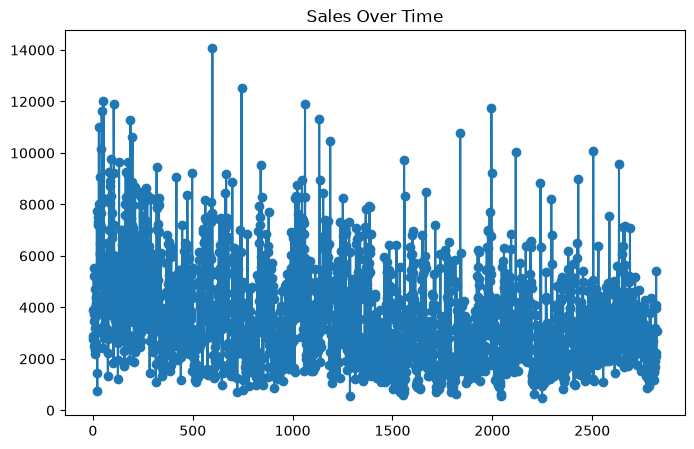

In [8]:
#to create a line graph of 1 column of SALES
df['SALES'].plot(x='YEAR_ID', kind='line', marker='o', figsize=(8, 5), title='Sales Over Time')


In [9]:
#Calculate new column 'Units Sold' and show only relevant columns for each order.
df['UNITSSOLD'] = df['SALES']/df['QUANTITYORDERED']
df[['ORDERNUMBER','UNITSSOLD','SALES']].head(3)

,ORDERNUMBER,UNITSSOLD,SALES
0,10107,95.70,2871.00
1,10121,81.35,2765.90
2,10134,94.74,3884.34


<Axes: >

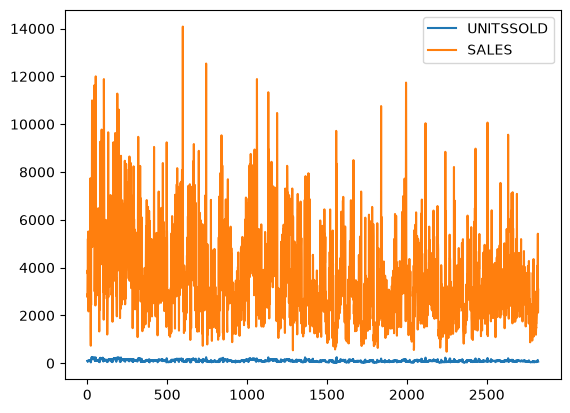

In [10]:
#To create a chart with 2 columns - Units SOLD and SALES 
sold = df[['UNITSSOLD','SALES']]
sold.plot()

C:\Users\mcnicholst\.conda\envs\notebook-env\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


<Axes: ylabel='PRODUCTLINE'>

C:\Users\mcnicholst\.conda\envs\notebook-env\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


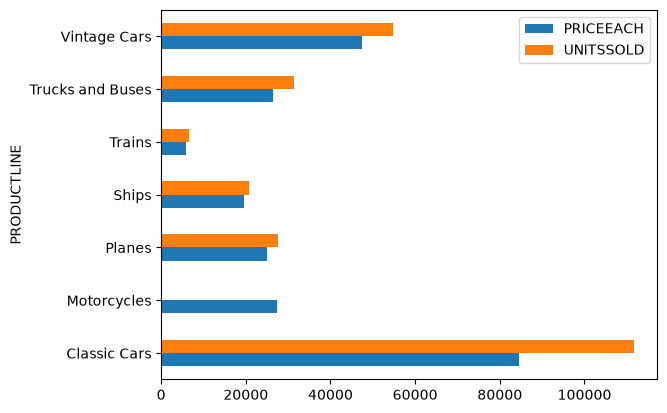

In [20]:
#use Groupby to collate the productline (.sum to get total) of Sales and Units Sold for each Product name.
#plot the difference in 'Products' according to 'SALES'
product = df[['PRODUCTLINE','PRICEEACH','UNITSSOLD']]
product.groupby(['PRODUCTLINE']).sum().plot(kind = 'barh')

<Axes: xlabel='COUNTRY'>

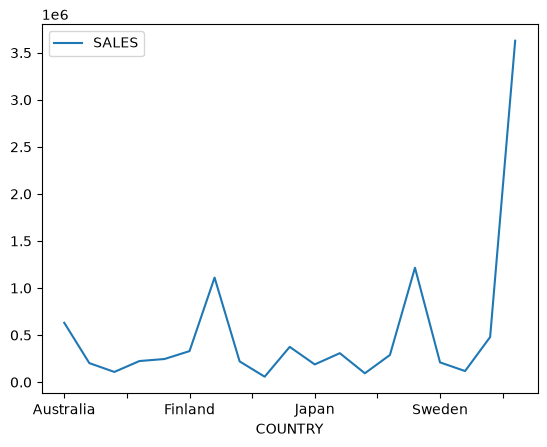

In [12]:
#plot the difference in 'COUNTRIES' according to 'SALES' - line chart.  2 columns in DF.
df_country = df[['COUNTRY','SALES']]
df_country.groupby(['COUNTRY']).sum().plot(kind = 'line')

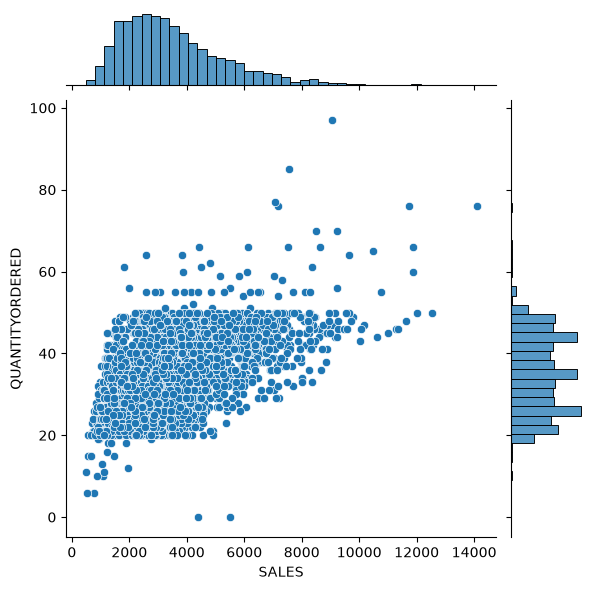

In [13]:

# Plotting the same thing now using a jointplot
#sns.jointplot(df.SALES, df.QUANTITYORDERED)

sns.jointplot(data=df, x='SALES', y='QUANTITYORDERED', kind='scatter')
plt.show()


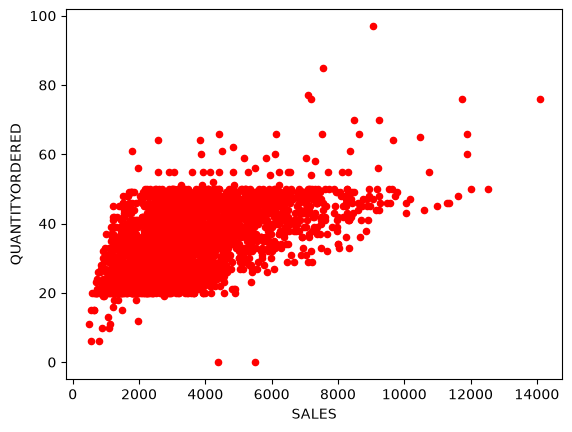

In [14]:
#plot a scatterplot for Sales & Quantity ORDERED.
df.plot(kind='scatter', x='SALES', y='QUANTITYORDERED', color='red')
plt.show()

In [15]:
#Find sales >240
topsales = df.loc[(df['UNITSSOLD'] > 245),['CONTACTFIRSTNAME','UNITSSOLD','SALES']].sort_values('SALES', ascending = False)
topsales

,CONTACTFIRSTNAME,UNITSSOLD,SALES
744,Valarie,250.73,12536.50
1133,Julie,246.45,11336.70
188,Jeff,245.20,11279.20
1561,Anna,252.87,8344.71
27,Christina,248.59,7209.11
1363,Mart¡n,245.20,7110.80
7,Veysel,inf,5512.32
190,Diego,245.20,4904.00
17,Jonas,inf,4394.38


C:\Users\mcnicholst\.conda\envs\notebook-env\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


<Axes: >

C:\Users\mcnicholst\.conda\envs\notebook-env\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


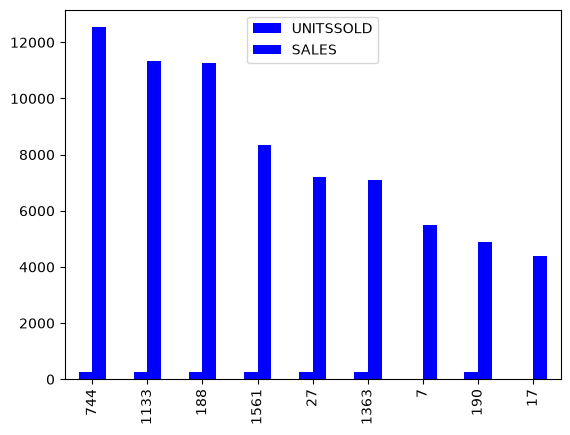

In [16]:
topsales.plot(kind='bar', color='blue')

C:\Users\mcnicholst\.conda\envs\notebook-env\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\mcnicholst\.conda\envs\notebook-env\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


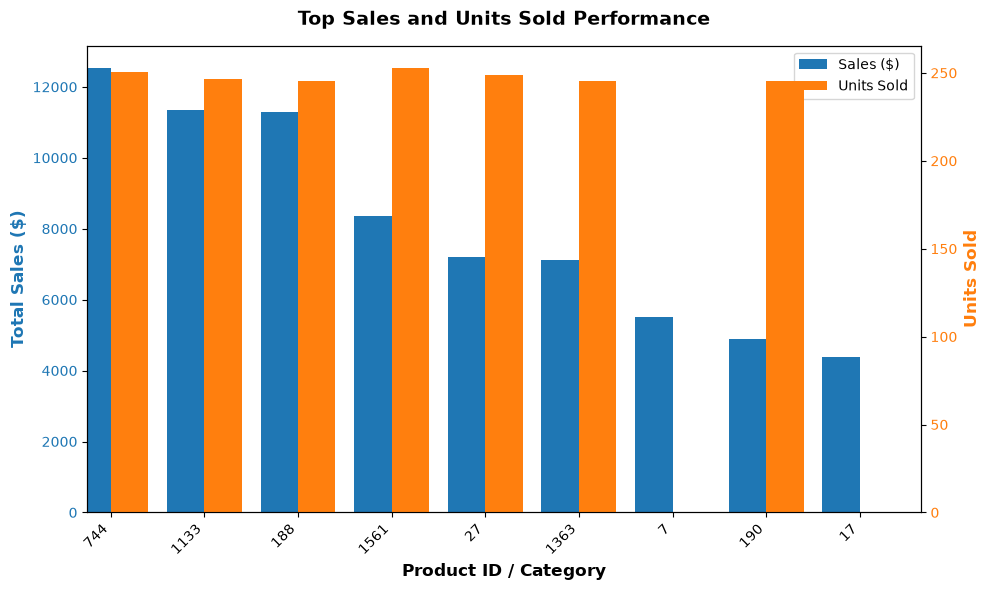

In [17]:
#Problem with this plot is Unitssold & Sales are different scales.
#Improve plots
fig, ax1 = plt.subplots(figsize=(10, 6))

#1. Plot SALES on the main left Y-axis (Primary)
color_sales = '#1f77b4' # Clean corporate blue
topsales['SALES'].plot(kind='bar', color=color_sales, ax=ax1, width=0.4, position=1, label='Sales ($)')
ax1.set_ylabel('Total Sales ($)', color=color_sales, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_sales)

#2. Create a secondary Y-axis for UNITSSOLD (Right side)
ax2 = ax1.twinx()
color_units = '#ff7f0e' # Contrasting safety orange
topsales['UNITSSOLD'].plot(kind='bar', color=color_units, ax=ax2, width=0.4, position=0, label='Units Sold')
ax2.set_ylabel('Units Sold', color=color_units, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_units)

#3. Refine formatting, labels, and titles
ax1.set_title('Top Sales and Units Sold Performance', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Product ID / Category', fontsize=12, fontweight='bold')

#4.Rotate X-axis tick labels so they are readable
ax1.set_xticklabels(topsales.index, rotation=45, ha='right')

#5. Combine legends from both axes into one clean box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


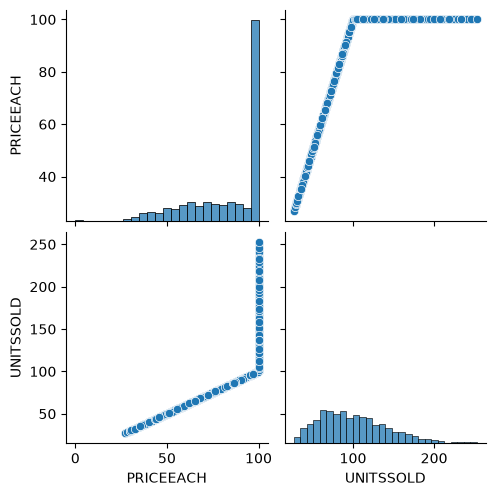

In [18]:
#The pairplot plot is used to compared only for all Integer & floating points in dataset.
#Is a dataframe that only has 3 columsn of variables - Price Each, Units Sold, country 
g = sns.pairplot(product)

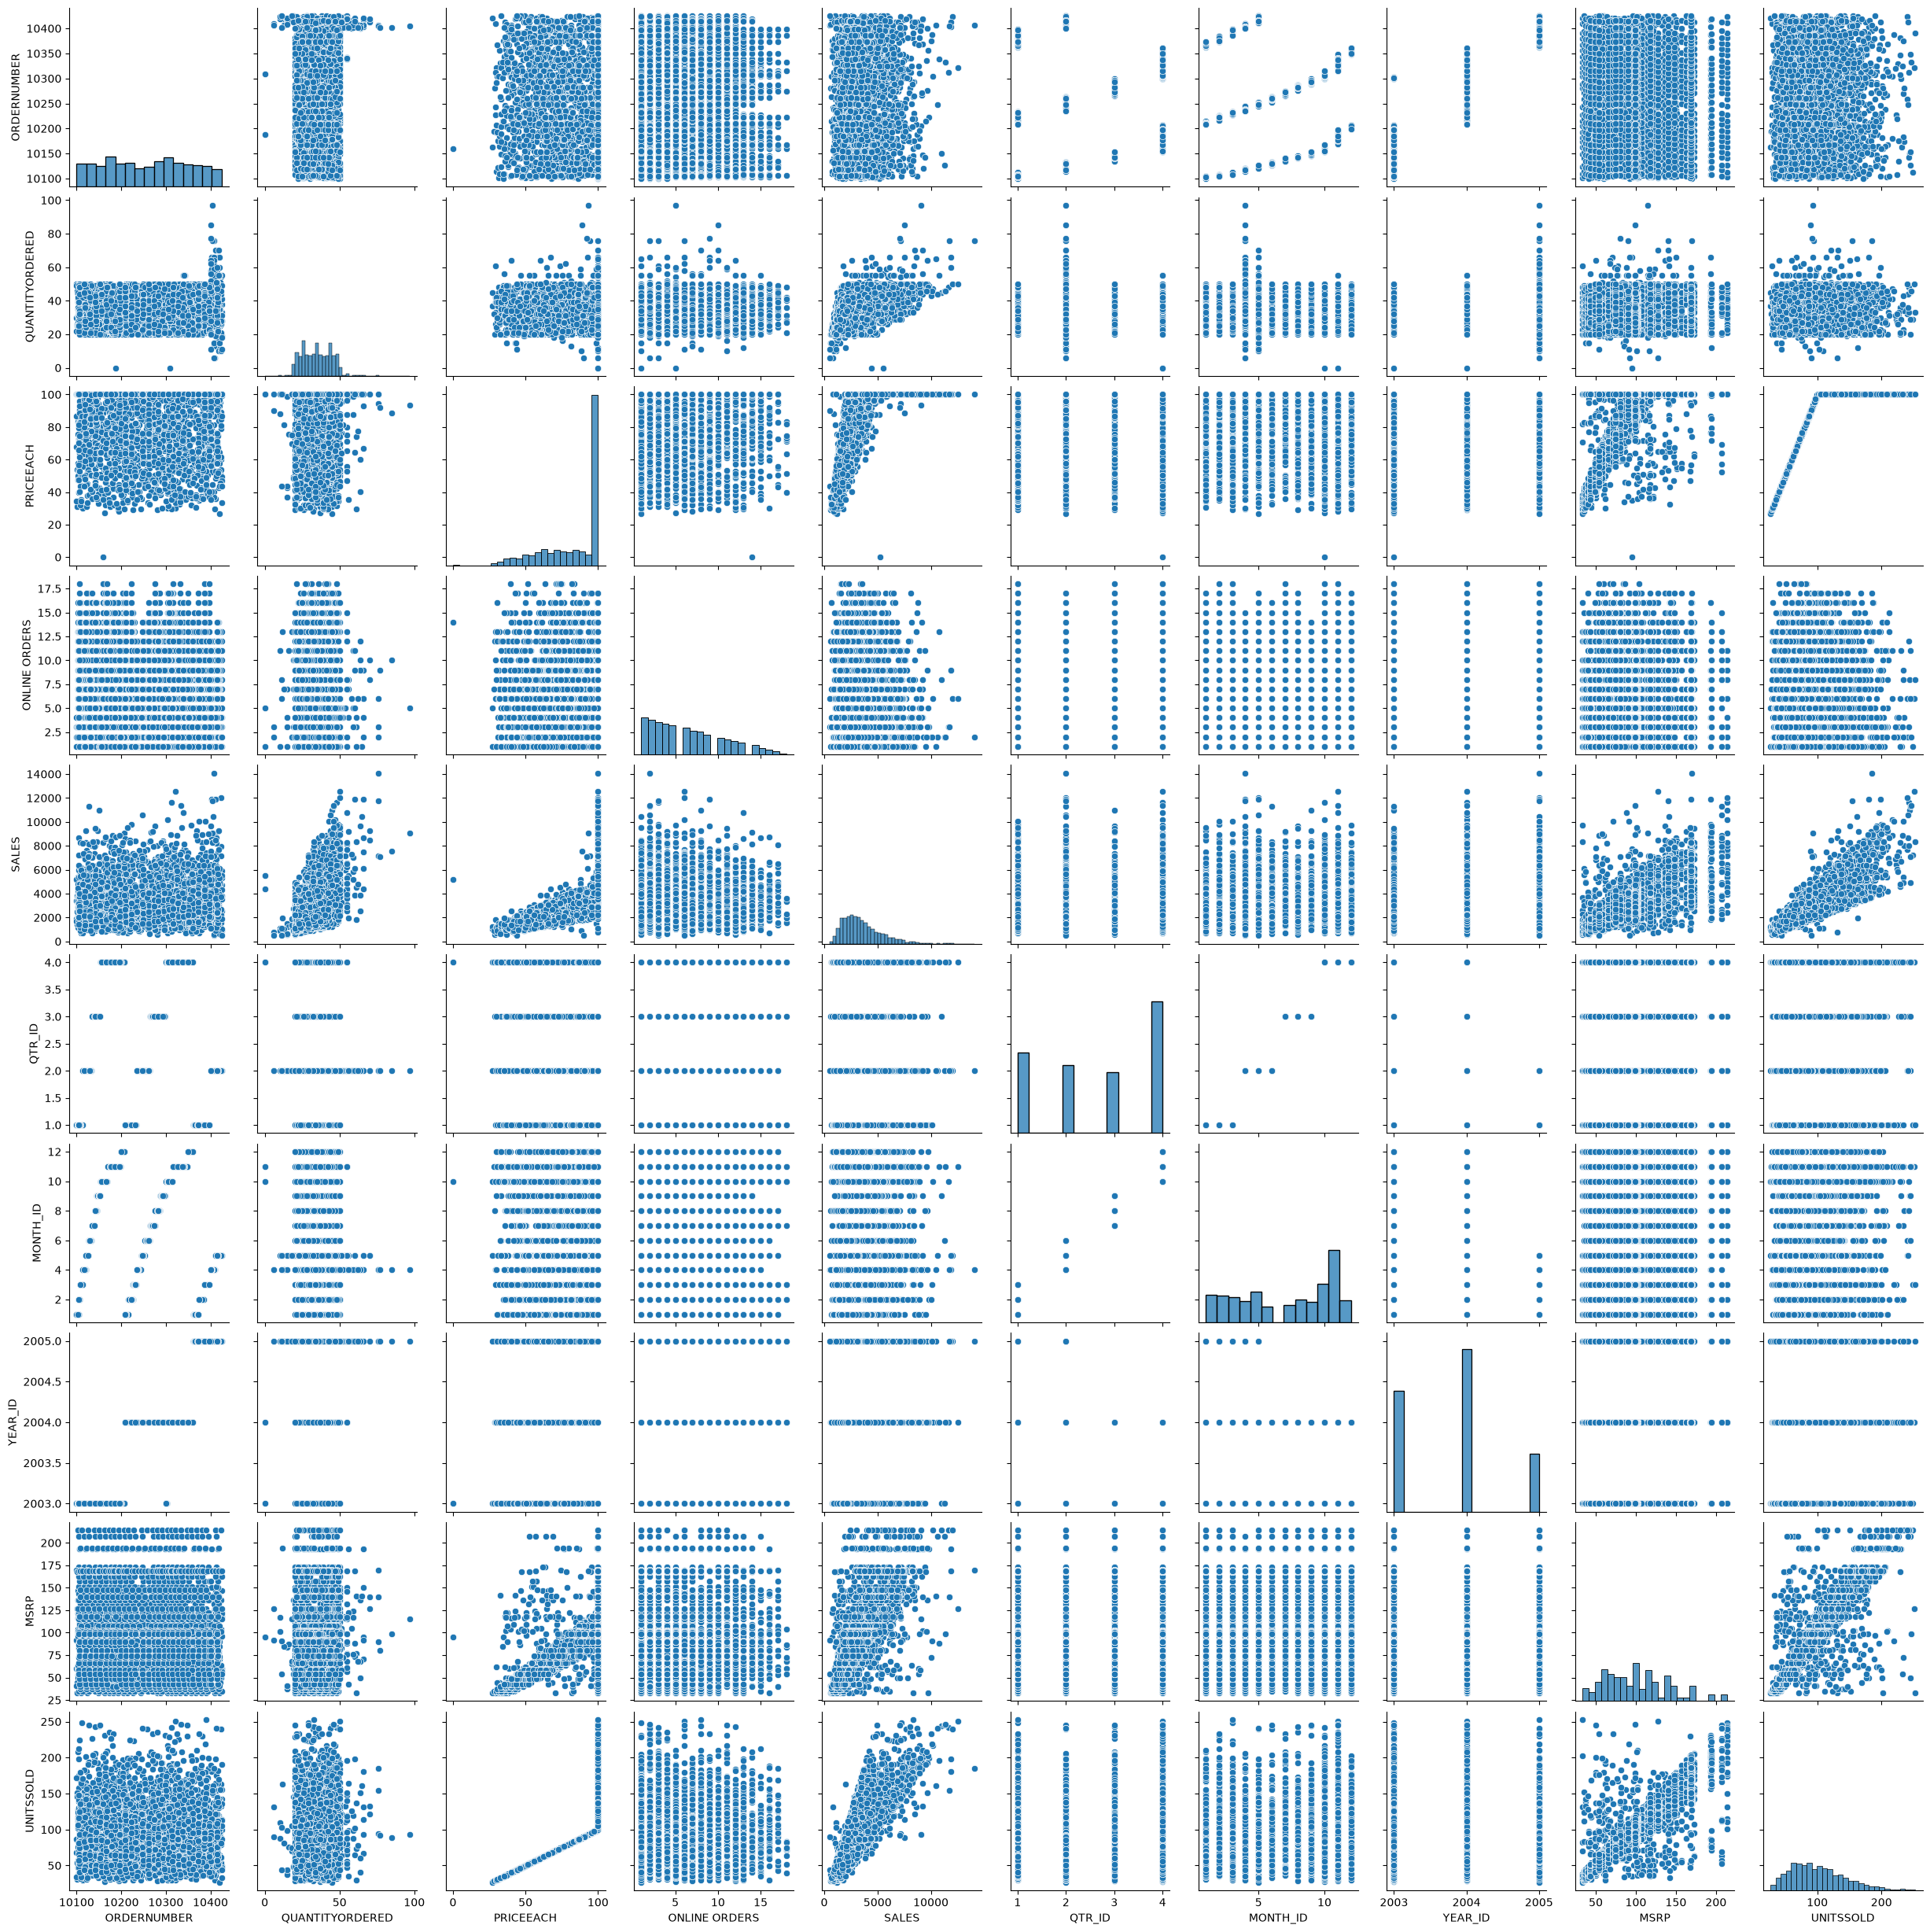

In [19]:
g = sns.pairplot(df)